In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Data Import

In [2]:
# Import Log_transformed data

hypo = '/content/drive/MyDrive/Data/Suman Dai Paper/hypo_Log.xlsx'
usnea = '/content/drive/MyDrive/Data/Suman Dai Paper/usnea_Log.xlsx'

df_hypo = pd.read_excel(hypo, sheet_name='Log')
df_usnea = pd.read_excel(usnea, sheet_name='Log')
df_hypo
df_usnea

,Ammonia,Nitrogen,Nitrate,Na,Mg,K,Ca,Mn,Fe,Ni,...,Zn,Pb,Cd,EC,Chl_t,Chl_d,Chl_f,TPC,DPPH,CAT
0,3.800442,1.991226,3.766413,2.920176,2.745855,2.015779,3.886856,1.346353,0.025470,0.000000,...,0.722634,1.870170,0.365488,3.759668,3.362671,2.120574,1.778151,4.212268,3.705094,1.544068
1,3.819544,1.991226,3.822168,2.901186,2.758215,2.014100,3.861564,1.188084,1.730298,0.000000,...,0.754348,1.706206,0.170262,3.763428,3.362859,2.123852,1.785330,4.236739,3.705094,1.623249
2,3.769377,1.991226,3.754348,2.910528,2.810219,2.036629,3.880304,1.281488,1.514282,0.000000,...,0.453318,1.604874,0.322219,3.765669,3.364176,2.123852,1.826075,4.246745,3.702689,1.544068
3,3.701050,1.662758,3.689131,2.966667,2.654119,2.627591,4.502959,1.999739,1.957990,0.000000,...,1.506505,2.239900,0.897627,3.625312,3.462697,2.033424,1.785330,4.135324,3.721893,1.748188
4,3.689841,1.672098,3.703119,2.946659,2.645815,2.639486,4.549363,2.007662,2.054230,0.000000,...,1.489677,2.239900,0.815578,3.633468,3.454692,2.037426,1.812913,4.123329,3.721893,1.755875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,4.021189,1.838219,4.028246,2.736569,3.101091,2.588928,4.111227,1.413434,2.040056,1.082139,...,1.262119,1.025060,0.136721,4.057666,3.375572,1.927370,1.770115,3.894011,3.612508,1.530200
86,4.027920,1.827369,4.027431,2.750900,3.078107,2.538654,4.068453,1.480381,1.902471,1.140194,...,1.280988,1.025060,0.101747,4.056905,3.384640,1.937518,1.744293,3.919026,3.603307,1.633468
87,3.938119,1.870989,3.926754,2.790129,3.020770,2.880852,4.107765,1.514441,1.957990,1.082139,...,1.114010,1.104214,-0.199283,4.100371,3.491081,1.970812,1.662758,3.901671,3.695219,1.871573
88,3.942306,1.875640,3.924486,2.832711,3.030329,2.878827,4.129378,1.497731,1.961450,1.082139,...,1.114010,1.104214,-0.199283,4.103462,3.470543,1.960471,1.681241,3.875605,3.714858,1.915400


### Normality Check

In [3]:
# CHECK NORMALITY

from scipy.stats import shapiro
import pandas as pd

# Assuming df is your DataFrame with 23 columns
for column in df_usnea.columns:
    stat, p_value = shapiro(df_usnea[column])
    alpha = 0.05  # Significance level for 95% confidence interval

    if p_value < alpha:
        print(f"{column}: Not normally distributed  (Statistic={stat:.4f}, p-value={p_value:.4f}")
    else:
        print(f"{column}: Normally distributed      (Statistic={stat:.4f}, p-value={p_value:.4f})")

Ammonia: Not normally distributed  (Statistic=0.8487, p-value=0.0000
Nitrogen: Not normally distributed  (Statistic=0.9436, p-value=0.0007
Nitrate: Not normally distributed  (Statistic=0.8727, p-value=0.0000
Na: Not normally distributed  (Statistic=0.9705, p-value=0.0381
Mg: Not normally distributed  (Statistic=0.9362, p-value=0.0003
K: Not normally distributed  (Statistic=0.9357, p-value=0.0002
Ca: Not normally distributed  (Statistic=0.9502, p-value=0.0017
Mn: Normally distributed      (Statistic=0.9749, p-value=0.0791)
Fe: Not normally distributed  (Statistic=0.7991, p-value=0.0000
Ni: Not normally distributed  (Statistic=0.7648, p-value=0.0000
Cu: Not normally distributed  (Statistic=0.8955, p-value=0.0000
Zn: Not normally distributed  (Statistic=0.9085, p-value=0.0000
Pb: Not normally distributed  (Statistic=0.9603, p-value=0.0077
Cd: Normally distributed      (Statistic=0.9802, p-value=0.1872)
EC: Not normally distributed  (Statistic=0.8998, p-value=0.0000
Chl_t: Not normally dis

In [4]:
df_hypo.columns

Index(['Ammonia', 'Nitrogen', 'Na', 'Mg', 'K', 'Ca', 'Mn', 'Fe', 'Cu', 'Zn',
       'Pb', 'Cd', 'EC', 'Chl_t', 'Chl_d', 'Chl_f', 'TPC', 'DPPH', 'CAT'],
      dtype='object')

### Histogram using for loop

In [6]:
for column in df.columns:
    plt.hist(df[column], bins='auto', alpha=0.7, label=column)
    plt.title(f'{column} Histogram')
    plt.xlabel('Variable Values')
    plt.ylabel('Frequency')
    plt.legend(loc='upper right')
    #plt.show()

NameError: name 'df' is not defined

### Multiple Regression and VIF

In [5]:
# MULTIPLE REGRESSION and VIF

import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Log-transform the predictor variables
#df_log = df.apply(lambda x: x.apply(lambda y: np.log(y) if y > 0 else 0))

# Add a constant for the intercept
X = sm.add_constant(df_hypo[['Ammonia', 'Nitrogen', 'Na', 'Mg', 'K', 'Ca', 'Mn', 'Fe',
                              'Cu', 'Zn', 'Pb', 'Cd']])

# Fit the multiple linear regression model
model = sm.OLS(df_hypo['Chl_t'], X).fit()

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Hypo_Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)
#print(model.summary())

   Hypo_Variable          VIF
0          const  3510.789355
1        Ammonia     5.367002
2       Nitrogen     4.196612
3             Na     2.380836
4             Mg     4.105674
5              K     2.501106
6             Ca     6.884200
7             Mn     2.928109
8             Fe     2.847354
9             Cu     1.834212
10            Zn     4.122634
11            Pb     2.016810
12            Cd     1.480423


In [ ]:
df_usnea.columns

Index(['Ammonia', 'Nitrogen', 'Nitrate', 'Na', 'Mg', 'K', 'Ca', 'Mn', 'Fe',
       'Ni', 'Cu', 'Zn', 'Pb', 'Cd', 'EC', 'Chl_t', 'Chl_d', 'Chl_f', 'TPC',
       'DPPH', 'CAT'],
      dtype='object')

###  Usnea_Multiple Regression

In [6]:
# USNEA_MULTIPLE REGRESSION

import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Log-transform the predictor variables
#df_log = df.apply(lambda x: x.apply(lambda y: np.log(y) if y > 0 else 0))

# Add a constant for the intercept
X = sm.add_constant(df_usnea[['Nitrogen', 'Na', 'Mg', 'Mn', 'Fe','Cu', 'Zn', 'Pb', 'Cd']])

# Fit the multiple linear regression model
model = sm.OLS(df_usnea['CAT'], X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    CAT   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                     11.95
Date:                Thu, 06 Feb 2025   Prob (F-statistic):           1.01e-11
Time:                        00:17:08   Log-Likelihood:                 11.351
No. Observations:                  90   AIC:                            -2.701
Df Residuals:                      80   BIC:                             22.30
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.0798      1.031     -2.018      0.0

In [9]:
df_hypo.columns

Index(['Ammonia', 'Nitrogen', 'Na', 'Mg', 'K', 'Ca', 'Mn', 'Fe', 'Cu', 'Zn',
       'Pb', 'Cd', 'EC', 'Chl_t', 'Chl_d', 'Chl_f', 'TPC', 'DPPH', 'CAT'],
      dtype='object')

### Hypo_Multiple Regression

In [7]:
# HYPO_MULTIPLE REGRESSION

import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Log-transform the predictor variables
#df_log = df.apply(lambda x: x.apply(lambda y: np.log(y) if y > 0 else 0))

# Add a constant for the intercept
X = sm.add_constant(df_hypo[['Nitrogen', 'Na', 'Mg', 'K', 'Mn', 'Fe','Cu', 'Zn', 'Pb', 'Cd']])

# Fit the multiple linear regression model
model = sm.OLS(df_hypo['CAT'], X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    CAT   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                     18.99
Date:                Thu, 06 Feb 2025   Prob (F-statistic):           3.27e-17
Time:                        00:17:11   Log-Likelihood:                 25.968
No. Observations:                  90   AIC:                            -29.94
Df Residuals:                      79   BIC:                            -2.439
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3539      0.991     -0.357      0.7

### Regression Plots

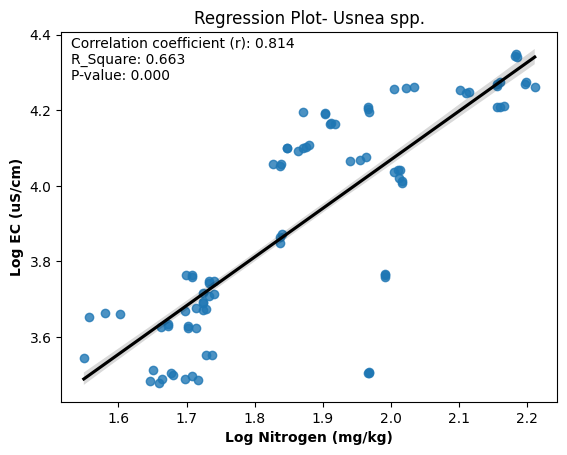

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress


# Create a scatter plot with a linear regression line
sns.regplot(data=df_usnea, x='Nitrogen', y='EC',ci=50, line_kws=dict(color='black'))

# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_usnea['Nitrogen'], df_usnea['EC'])
r_square = r_value**2

# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.87), xycoords='axes fraction', fontsize=10, color='black')

plt.title('Regression Plot- Usnea spp.')
plt.xlabel('Log Nitrogen (mg/kg)', weight='bold')
plt.ylabel('Log EC (uS/cm)', weight='bold')
plt.savefig('regression_Nitrogen_vs_EC1.png',dpi=1200)

# Show the plot
plt.show()

### Subplots without Iteration for Usnea

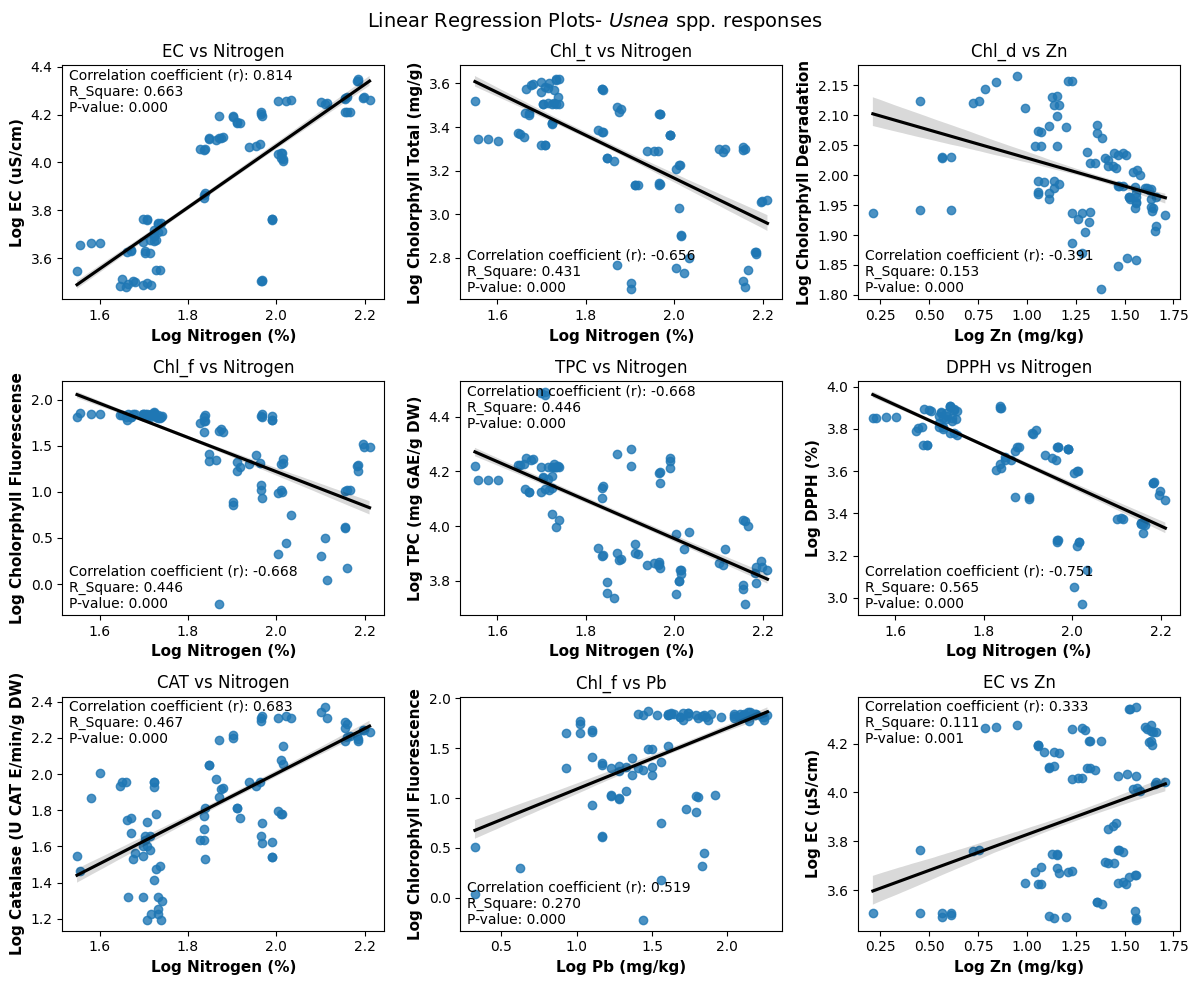

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.figure(figsize=(12,10))

plt.subplot(3,3,1)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_usnea, x='Nitrogen', y='EC',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_usnea['Nitrogen'], df_usnea['EC'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.80), xycoords='axes fraction', fontsize=10, color='black')
plt.title('EC vs Nitrogen', fontsize=12)
plt.xlabel('Log Nitrogen (%)', weight='bold', fontsize=11)
plt.ylabel('Log EC (uS/cm)', weight='bold', fontsize=11)


plt.subplot(3,3,2)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_usnea, x='Nitrogen', y='Chl_t',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_usnea['Nitrogen'], df_usnea['Chl_t'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.03), xycoords='axes fraction', fontsize=10, color='black')
plt.title('Chl_t vs Nitrogen', fontsize=12)
plt.xlabel('Log Nitrogen (%)', weight='bold', fontsize=11)
plt.ylabel('Log Cholorphyll Total (mg/g)', weight='bold', fontsize=11)


plt.subplot(3,3,3)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_usnea, x='Zn', y='Chl_d',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_usnea['Zn'], df_usnea['Chl_d'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.03), xycoords='axes fraction', fontsize=10, color='black')
plt.title('Chl_d vs Zn', fontsize=12)
plt.xlabel('Log Zn (mg/kg)', weight='bold', fontsize=11)
plt.ylabel('Log Cholorphyll Degradation', weight='bold', fontsize=11)


plt.subplot(3,3,4)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_usnea, x='Nitrogen', y='Chl_f',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_usnea['Nitrogen'], df_usnea['Chl_f'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.03), xycoords='axes fraction', fontsize=10, color='black')
plt.title('Chl_f vs Nitrogen', fontsize=12)
plt.xlabel('Log Nitrogen (%)', weight='bold', fontsize=11)
plt.ylabel('Log Cholorphyll Fluorescense', weight='bold', fontsize=11)


plt.subplot(3,3,5)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_usnea, x='Nitrogen', y='TPC',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_usnea['Nitrogen'], df_usnea['TPC'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.80), xycoords='axes fraction', fontsize=10, color='black')
plt.title('TPC vs Nitrogen', fontsize=12)
plt.xlabel('Log Nitrogen (%)', weight='bold', fontsize=11)
plt.ylabel('Log TPC (mg GAE/g DW)', weight='bold', fontsize=11)


plt.subplot(3,3,6)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_usnea, x='Nitrogen', y='DPPH',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_usnea['Nitrogen'], df_usnea['DPPH'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.03), xycoords='axes fraction', fontsize=10, color='black')
plt.title('DPPH vs Nitrogen', fontsize=12)
plt.xlabel('Log Nitrogen (%)', weight='bold', fontsize=11)
plt.ylabel('Log DPPH (%)', weight='bold', fontsize=11)


plt.subplot(3,3,7)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_usnea, x='Nitrogen', y='CAT',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_usnea['Nitrogen'], df_usnea['CAT'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.80), xycoords='axes fraction', fontsize=10, color='black')
plt.title('CAT vs Nitrogen', fontsize=12)
plt.xlabel('Log Nitrogen (%)', weight='bold', fontsize=11)
plt.ylabel('Log Catalase (U CAT E/min/g DW)', weight='bold', fontsize=11)


plt.subplot(3,3,8)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_usnea, x='Pb', y='Chl_f',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_usnea['Pb'], df_usnea['Chl_f'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.03), xycoords='axes fraction', fontsize=10, color='black')
plt.title('Chl_f vs Pb', fontsize=12)
plt.xlabel('Log Pb (mg/kg)', weight='bold', fontsize=11)
plt.ylabel('Log Chlorophyll Fluorescence', weight='bold', fontsize=11)


plt.subplot(3,3,9)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_usnea, x='Zn', y='EC',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_usnea['Zn'], df_usnea['EC'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.80), xycoords='axes fraction', fontsize=10, color='black')
plt.title('EC vs Zn', fontsize=12)
plt.xlabel('Log Zn (mg/kg)', weight='bold', fontsize=11)
plt.ylabel('Log EC (µS/cm)', weight='bold', fontsize=11)

#plt.subplots_adjust(wspace=0.25, hspace=0.35)

# Show the plot
title_text = r'Linear Regression Plots- $\mathrm{\mathit{Usnea}}$ spp. responses'
plt.suptitle(title_text, fontsize=14)
plt.tight_layout()
plt.savefig('subplots_usnea.png', bbox_inches= 'tight',dpi=1200)

plt.show()

### Subplots without Iteration for Hypo

In [11]:
df_hypo.columns

Index(['Ammonia', 'Nitrogen', 'Na', 'Mg', 'K', 'Ca', 'Mn', 'Fe', 'Cu', 'Zn',
       'Pb', 'Cd', 'EC', 'Chl_t', 'Chl_d', 'Chl_f', 'TPC', 'DPPH', 'CAT'],
      dtype='object')

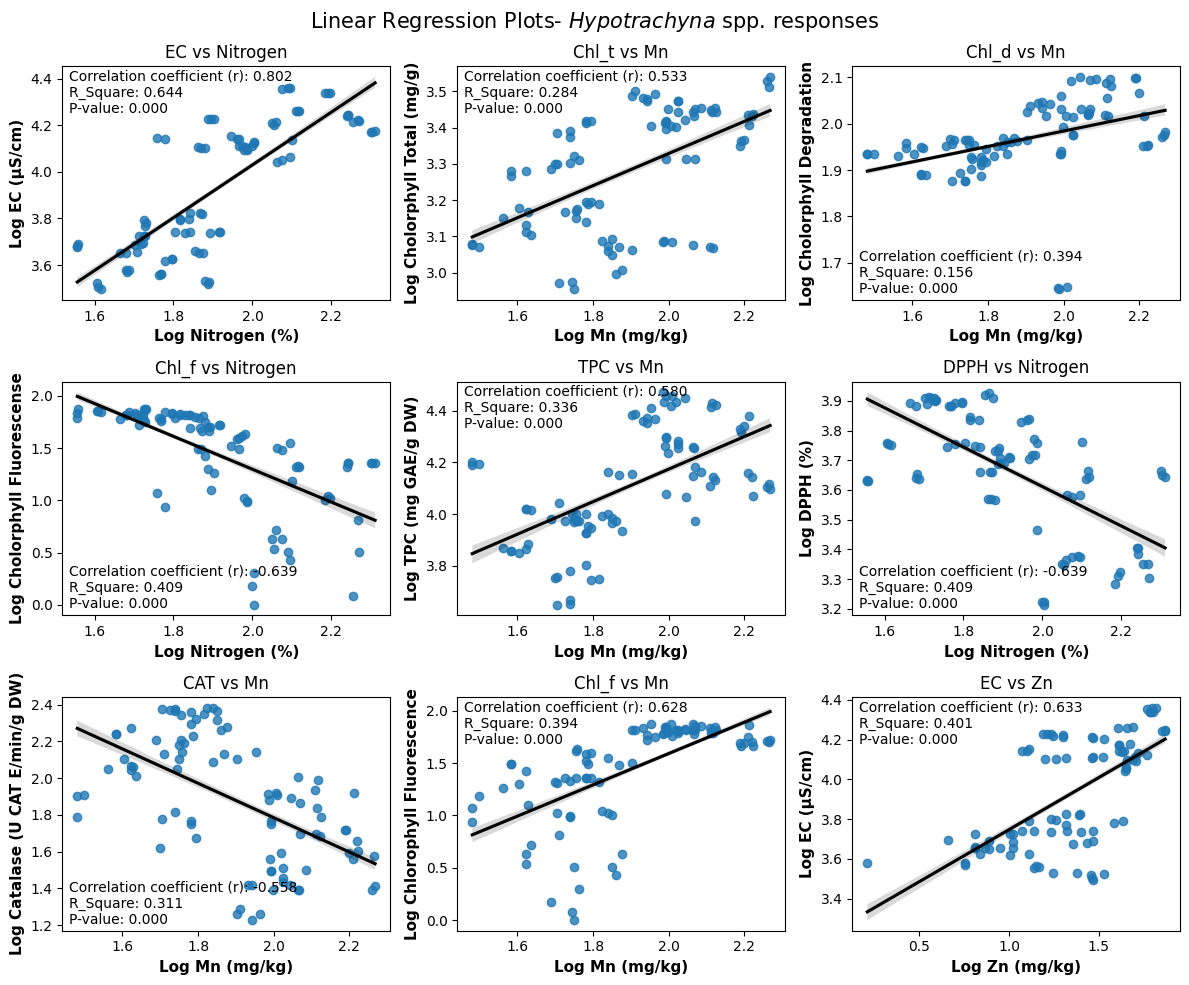

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.figure(figsize=(12,10))

plt.subplot(3,3,1)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_hypo, x='Nitrogen', y='EC',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_hypo['Nitrogen'], df_hypo['EC'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.80), xycoords='axes fraction', fontsize=10, color='black')
plt.title('EC vs Nitrogen', fontsize=12)
plt.xlabel('Log Nitrogen (%)', weight='bold', fontsize=11)
plt.ylabel('Log EC (µS/cm)', weight='bold', fontsize=11)


plt.subplot(3,3,2)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_hypo, x='Mn', y='Chl_t',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_hypo['Mn'], df_hypo['Chl_t'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.80), xycoords='axes fraction', fontsize=10, color='black')
plt.title('Chl_t vs Mn', fontsize=12)
plt.xlabel('Log Mn (mg/kg)', weight='bold', fontsize=11)
plt.ylabel('Log Cholorphyll Total (mg/g)', weight='bold', fontsize=11)


plt.subplot(3,3,3)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_hypo, x='Mn', y='Chl_d',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_hypo['Mn'], df_hypo['Chl_d'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.03), xycoords='axes fraction', fontsize=10, color='black')
plt.title('Chl_d vs Mn', fontsize=12)
plt.xlabel('Log Mn (mg/kg)', weight='bold', fontsize=11)
plt.ylabel('Log Cholorphyll Degradation', weight='bold', fontsize=11)


plt.subplot(3,3,4)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_hypo, x='Nitrogen', y='Chl_f',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_hypo['Nitrogen'], df_hypo['Chl_f'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.03), xycoords='axes fraction', fontsize=10, color='black')
plt.title('Chl_f vs Nitrogen', fontsize=12)
plt.xlabel('Log Nitrogen (%)', weight='bold', fontsize=11)
plt.ylabel('Log Cholorphyll Fluorescense', weight='bold', fontsize=11)


plt.subplot(3,3,5)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_hypo, x='Mn', y='TPC',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_hypo['Mn'], df_hypo['TPC'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.80), xycoords='axes fraction', fontsize=10, color='black')
plt.title('TPC vs Mn', fontsize=12)
plt.xlabel('Log Mn (mg/kg)', weight='bold', fontsize=11)
plt.ylabel('Log TPC (mg GAE/g DW)', weight='bold', fontsize=11)


plt.subplot(3,3,6)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_hypo, x='Nitrogen', y='DPPH',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_hypo['Nitrogen'], df_hypo['DPPH'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.03), xycoords='axes fraction', fontsize=10, color='black')
plt.title('DPPH vs Nitrogen', fontsize=12)
plt.xlabel('Log Nitrogen (%)', weight='bold', fontsize=11)
plt.ylabel('Log DPPH (%)', weight='bold', fontsize=11)


plt.subplot(3,3,7)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_hypo, x='Mn', y='CAT',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_hypo['Mn'], df_hypo['CAT'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.03), xycoords='axes fraction', fontsize=10, color='black')
plt.title('CAT vs Mn', fontsize=12)
plt.xlabel('Log Mn (mg/kg)', weight='bold', fontsize=11)
plt.ylabel('Log Catalase (U CAT E/min/g DW)', weight='bold', fontsize=11)


plt.subplot(3,3,8)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_hypo, x='Mn', y='Chl_f',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_hypo['Mn'], df_hypo['Chl_f'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.80), xycoords='axes fraction', fontsize=10, color='black')
plt.title('Chl_f vs Mn', fontsize=12)
plt.xlabel('Log Mn (mg/kg)', weight='bold', fontsize=11)
plt.ylabel('Log Chlorophyll Fluorescence', weight='bold', fontsize=11)


plt.subplot(3,3,9)
# Create a scatter plot with a linear regression line
sns.regplot(data=df_hypo, x='Zn', y='EC',ci=50, line_kws=dict(color='black'))
# Calculate linear regression statistics
slope, intercept, r_value, p_value, std_err = linregress(df_hypo['Zn'], df_hypo['EC'])
r_square = r_value**2
# Annotate the plot with the correlation coefficient (r) and p-value
plt.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
             xy=(0.02, 0.80), xycoords='axes fraction', fontsize=10, color='black')
plt.title('EC vs Zn', fontsize=12)
plt.xlabel('Log Zn (mg/kg)', weight='bold', fontsize=11)
plt.ylabel('Log EC (µS/cm)', weight='bold', fontsize=11)

#plt.subplots_adjust(wspace=0.25, hspace=0.35)

# Show the plot
title_text = r'Linear Regression Plots- $\mathbf{\mathit{Hypotrachyna}}$ spp. responses'
plt.suptitle(title_text, fontsize=15)
plt.tight_layout()
plt.savefig('subplots_hypotrachyna.png', bbox_inches= 'tight',dpi=1200)

plt.show()

### Subplots with Iteration

In [ ]:
df_usnea.columns

Index(['Ammonia', 'Nitrogen', 'Nitrate', 'Na', 'Mg', 'K', 'Ca', 'Mn', 'Fe',
       'Ni', 'Cu', 'Zn', 'Pb', 'Cd', 'EC', 'Chl_t', 'Chl_d', 'Chl_f', 'TPC',
       'DPPH', 'CAT'],
      dtype='object')

In [ ]:
sig_var = df_usnea[['Nitrogen', 'Zn','EC', 'Chl_t', 'Chl_d', 'Chl_f', 'TPC', 'DPPH', 'CAT']]
sig_var

,Nitrogen,Zn,EC,Chl_t,Chl_d,Chl_f,TPC,DPPH,CAT
0,1.991226,2.421604,3.759668,3.362671,2.120574,1.778151,4.212268,3.705094,1.544068
1,1.991226,2.453318,3.763428,3.362859,2.123852,1.785330,4.236739,3.705094,1.623249
2,1.991226,2.152288,3.765669,3.364176,2.123852,1.826075,4.246745,3.702689,1.544068
3,1.662758,3.205475,3.625312,3.462697,2.033424,1.785330,4.135324,3.721893,1.748188
4,1.672098,3.188647,3.633468,3.454692,2.037426,1.812913,4.123329,3.721893,1.755875
...,...,...,...,...,...,...,...,...,...
85,1.838219,2.961089,4.057666,3.375572,1.927370,1.770115,3.894011,3.612508,1.530200
86,1.827369,2.979958,4.056905,3.384640,1.937518,1.744293,3.919026,3.603307,1.633468
87,1.870989,2.812980,4.100371,3.491081,1.970812,1.662758,3.901671,3.695219,1.871573
88,1.875640,2.812980,4.103462,3.470543,1.960471,1.681241,3.875605,3.714858,1.915400


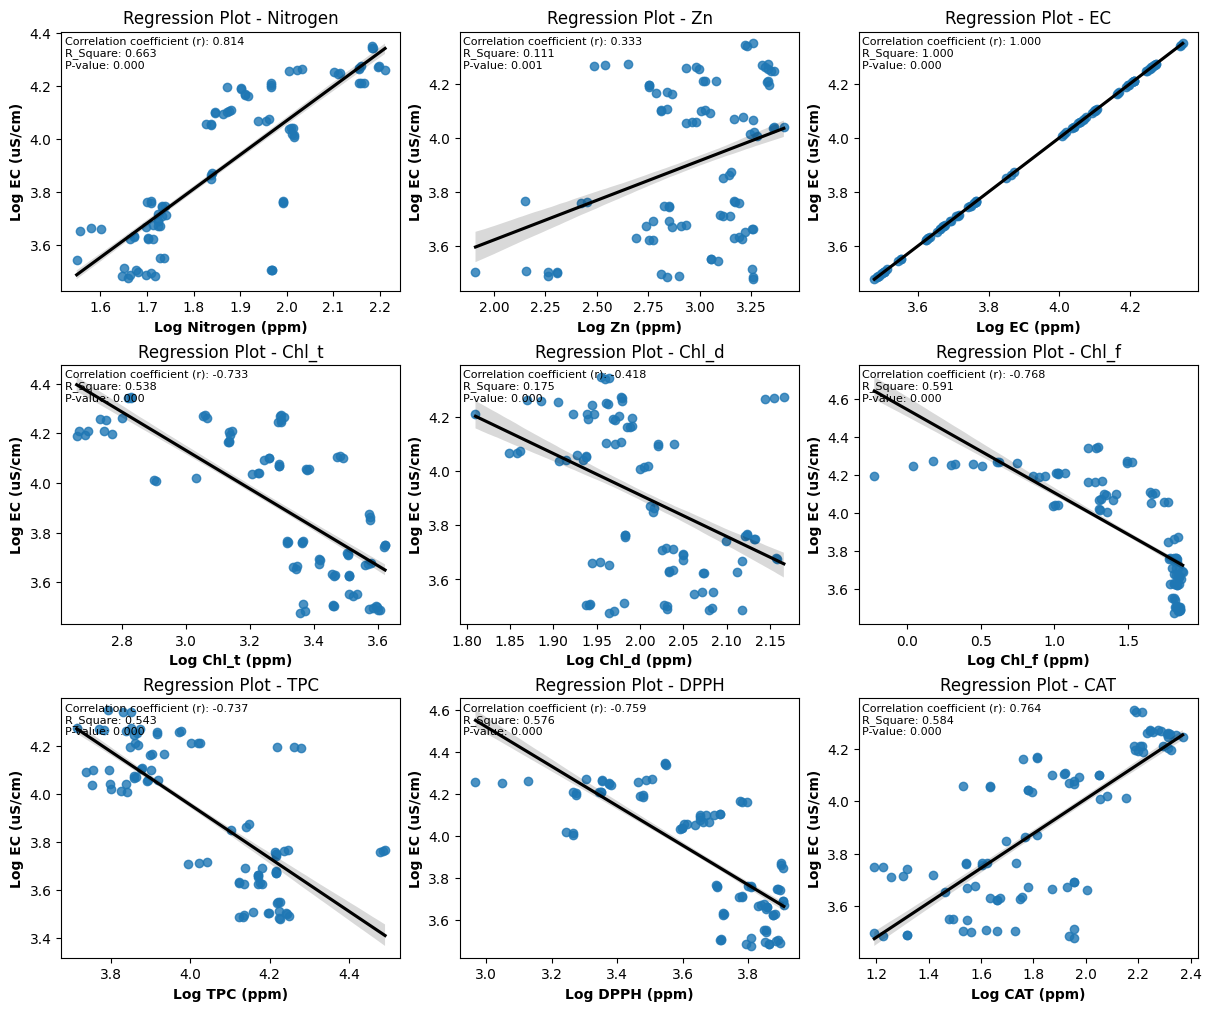

In [ ]:
import seaborn as sns
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Assuming df_usnea is a DataFrame containing your data
variables = ['Nitrogen', 'Zn', 'EC', 'Chl_t', 'Chl_d', 'Chl_f', 'TPC', 'DPPH', 'CAT']  # Add more variable names as needed

# Create a figure and axes for subplots
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 10), constrained_layout=True)

def plot_regression(ax, variable):
    # Scatter plot and linear regression
    sns.regplot(data=df_usnea, x=variable, y='EC', ci=50, line_kws=dict(color='black'), ax=ax)

    # Calculate linear regression statistics
    slope, intercept, r_value, p_value, std_err = linregress(df_usnea[variable], df_usnea['EC'])
    r_square = r_value**2

    # Annotate the plot with the correlation coefficient (r) and p-value
    ax.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
                xy=(0.01, 0.86), xycoords='axes fraction', fontsize=8, color='black')

    ax.set_title(f'Regression Plot - {variable}')
    ax.set_xlabel(f'Log {variable} (ppm)', weight='bold')
    ax.set_ylabel('Log EC (uS/cm)', weight='bold')

# Iterate through the subplots and plot the regressions
for i, row in enumerate(axs):
    for j, ax in enumerate(row):
        if i * len(row) + j < len(variables):
            plot_regression(ax, variables[i * len(row) + j])
        else:
            ax.set_visible(False)

# Save the figure
#plt.savefig('subplots_regression.png', dpi=600)

# Show the plot
plt.show()


In [ ]:
import seaborn as sns
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Assuming df_usnea is a DataFrame containing your data
variables = ['Nitrogen', 'Zn', 'EC', 'Chl_t', 'Chl_d', 'Chl_f', 'TPC', 'DPPH', 'CAT']  # Add more variable names as needed

# Create a figure and axes for subplots
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 10), constrained_layout=True)

def plot_regression(ax, variable):
    # Scatter plot and linear regression
    sns.regplot(data=df_usnea, x=variable, y='EC', ci=50, line_kws=dict(color='black'), ax=ax)

    # Calculate linear regression statistics
    slope, intercept, r_value, p_value, std_err = linregress(df_usnea[variable], df_usnea['EC'])
    r_square = r_value**2

    # Annotate the plot with the correlation coefficient (r) and p-value
    ax.annotate(f"Correlation coefficient (r): {r_value:.3f}\nR_Square: {r_square:.3f}\nP-value: {p_value:.3f}",
                xy=(0.01, 0.86), xycoords='axes fraction', fontsize=8, color='black')

    ax.set_title(f'Regression Plot - {variable}')
    ax.set_xlabel(f'Log {variable} (ppm)', weight='bold')
    ax.set_ylabel('Log EC (uS/cm)', weight='bold')

# Iterate through the subplots and plot the regressions
for i, row in enumerate(axs):
    for j, ax in enumerate(row):
        if i * len(row) + j < len(variables):
            plot_regression(ax, variables[i * len(row) + j])
        else:
            ax.set_visible(False)

# Save the figure
#plt.savefig('subplots_regression.png', dpi=600)

# Show the plot
plt.show()
